# Notebook 07b  — Agricultural Statistics Figures



## Cell 0. Configuration

In [27]:
# ── Configuration ────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
STATS_DIR = BASE_DIR / "AgriStats"
FIG_DIR   = STATS_DIR / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES  = ["Maize","Maize+Pumpkin","Beans+Maize",
                "Cassava+Maize","Grass","Mixed"]
CLASS_COLORS = ["#FFD700","#FF8C00","#1F78B4",
                "#A52A2A","#228B22","#808080"]
SPLIT_MAP = {
    "11226291":"Train","9965805":"Train","9805753":"Train",
    "10565691":"Train","10305790":"Train","10865406":"Train",
    "10165835":"Train","10085703":"Train","10185850":"Train",
    "9545448":"Train","10445787":"Train","11125706":"Train",
    "10165859":"Train","10145814":"Val","10595716":"Val",
    "10765685":"Val","10125706":"Test","10605304":"Test",
    "10865805":"Test",
}
TEST_SAS = ["10125706","10605304","10865805"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.color":        "#CCCCCC",
    "axes.labelsize":    11,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
})
print("Config ready. Figures -> ", FIG_DIR)

Config ready. Figures ->  E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures


## Cell 1. Load CSVs

In [28]:
# ── Load CSVs ────────────────────────────────────────────────────────────
area_df    = pd.read_csv(STATS_DIR / "crop_area_per_sa.csv")
forage_df  = pd.read_csv(STATS_DIR / "forage_stats_per_sa.csv")
farming_df = pd.read_csv(STATS_DIR / "farming_system_classification.csv")
fcover_df  = pd.read_csv(STATS_DIR / "fcover_stats_per_sa.csv")

# Subsets
area_label = area_df[area_df["source"]=="label"].copy()
area_rgb   = area_df[area_df["source"]=="rgb_pred"].copy()
area_ms    = area_df[area_df["source"]=="ms_pred"].copy()
forage_lbl = forage_df[forage_df["source"]=="label"].copy()
farming_lbl= farming_df[farming_df["source"]=="label"].copy()

print(f"Label rows   : {len(area_label)}")
print(f"RGB pred rows: {len(area_rgb)}")
print(f"MS pred rows : {len(area_ms)}")
print(f"FCover rows  : {len(fcover_df)}")

Label rows   : 19
RGB pred rows: 19
MS pred rows : 19
FCover rows  : 6


## Cell 2. Recompute Shannon H for ALL sources

Fixes the label-only diversity issue.

In [29]:
# ── Recompute Shannon H for ALL sources from area_df ─────────────────────
# This fixes the label-only diversity issue — now computed for all 3 sources

def shannon_h(row):
    crop_names = ["Maize","Maize+Pumpkin","Beans+Maize","Cassava+Maize","Mixed"]
    props = [row.get(f"{n}_pct", 0.0) for n in crop_names]
    total = sum(props)
    if total == 0: return 0.0
    h = 0.0
    for p in props:
        f = p / total
        if f > 0: h -= f * math.log(f)
    return round(h, 4)

area_df["Shannon_H"]     = area_df.apply(shannon_h, axis=1)
area_df["Max_H"]         = round(math.log(5), 4)
area_df["Evenness"]      = area_df["Shannon_H"].apply(
    lambda h: round(h / math.log(5), 4) if h > 0 else 0.0)
crop_names = ["Maize","Maize+Pumpkin","Beans+Maize","Cassava+Maize","Mixed"]
area_df["Crop_richness"] = area_df.apply(
    lambda r: sum(1 for n in crop_names
                  if r.get(f"{n}_pct",0) > 0.1), axis=1)

# Save updated diversity table
div_all = area_df[["SA","split","source",
                    "Shannon_H","Evenness","Crop_richness"]].copy()
div_all.to_csv(STATS_DIR/"crop_diversity_all_sources.csv", index=False)
print("Saved -> crop_diversity_all_sources.csv")

print("\nMean Shannon H by source:")
print(div_all.groupby("source")["Shannon_H"].mean().round(4).to_string())
print("\nMean Crop Richness by source:")
print(div_all.groupby("source")["Crop_richness"].mean().round(2).to_string())

Saved -> crop_diversity_all_sources.csv

Mean Shannon H by source:
source
label       0.5728
ms_pred     0.8035
rgb_pred    0.5432

Mean Crop Richness by source:
source
label       2.79
ms_pred     3.84
rgb_pred    3.32


## Figure 1a. Crop composition — LABEL

Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig1a_composition_label.png


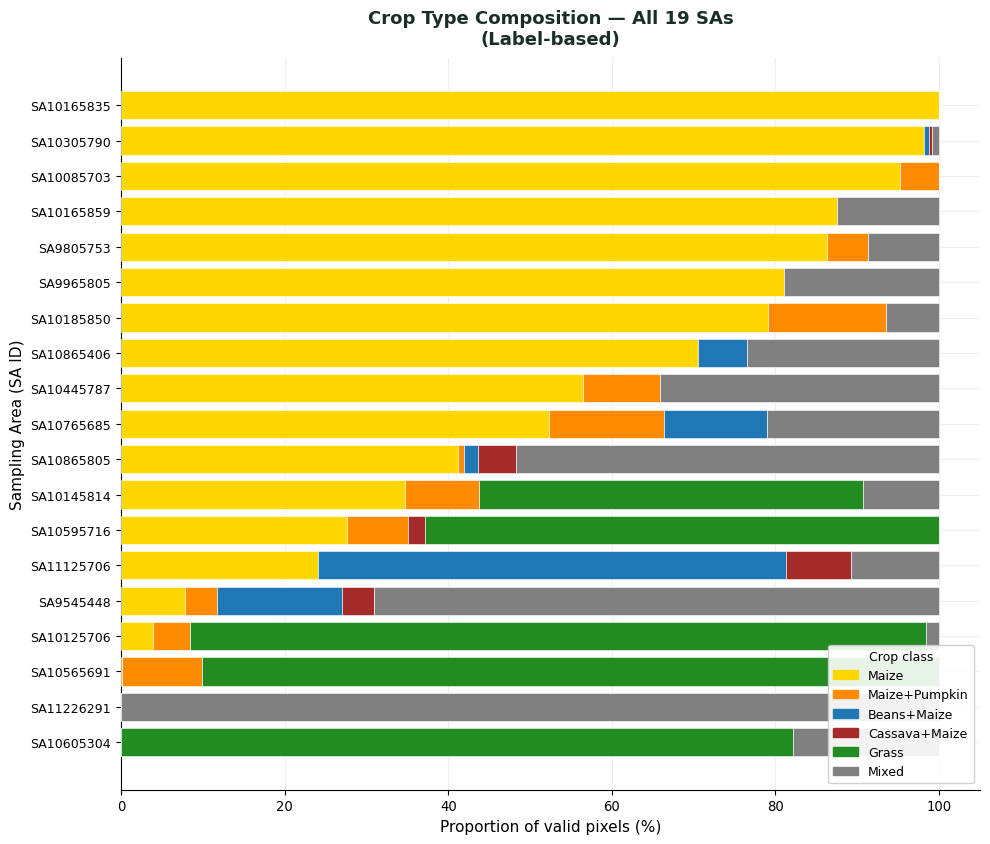

In [30]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 1a — Crop type composition — LABEL BASED
# ══════════════════════════════════════════════════════════════════
def crop_comp_chart(src_df, title, save_name, source_label):
    plot_df = src_df.sort_values("Maize_pct", ascending=True).copy()
    n_sa    = len(plot_df)

    fig, ax = plt.subplots(figsize=(10, max(5, n_sa*0.45)),
                            facecolor="white")
    x      = np.arange(n_sa)
    bottom = np.zeros(n_sa)

    for name, color in zip(CLASS_NAMES, CLASS_COLORS):
        col  = f"{name}_pct"
        vals = plot_df[col].values if col in plot_df.columns                else np.zeros(n_sa)
        ax.barh(x, vals, left=bottom, color=color,
                edgecolor="white", linewidth=0.4,
                label=name, zorder=3)
        bottom += vals

    ax.set_yticks(x)
    ax.set_yticklabels(
        [f"SA{sa}"
         for sa in plot_df["SA"].astype(str).values],
        fontsize=9)
    ax.set_xlabel("Proportion of valid pixels (%)", fontsize=11)
    ax.set_ylabel("Sampling Area (SA ID)", fontsize=11)
    ax.set_xlim(0, 105)
    ax.set_title(
        f"Crop Type Composition — All 19 SAs\n({source_label})",
        fontsize=13, fontweight="bold", color="#1A2F23", pad=10)

    patches = [mpatches.Patch(color=CLASS_COLORS[i],
               label=CLASS_NAMES[i]) for i in range(len(CLASS_NAMES))]
    ax.legend(handles=patches, loc="lower right",
              fontsize=9, frameon=True,
              framealpha=0.9, edgecolor="#CCCCCC",
              title="Crop class", title_fontsize=9)

    ax.set_axisbelow(True)
    plt.tight_layout()
    save = FIG_DIR / save_name
    plt.savefig(save, dpi=180, bbox_inches="tight")
    print(f"Saved: {save}")
    plt.show()

crop_comp_chart(area_label, "Label-based",
                "fig1a_composition_label.png",
                "Label-based")

## Figure 1b. Crop composition — RGB PREDICTION

Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig1b_composition_rgb.png


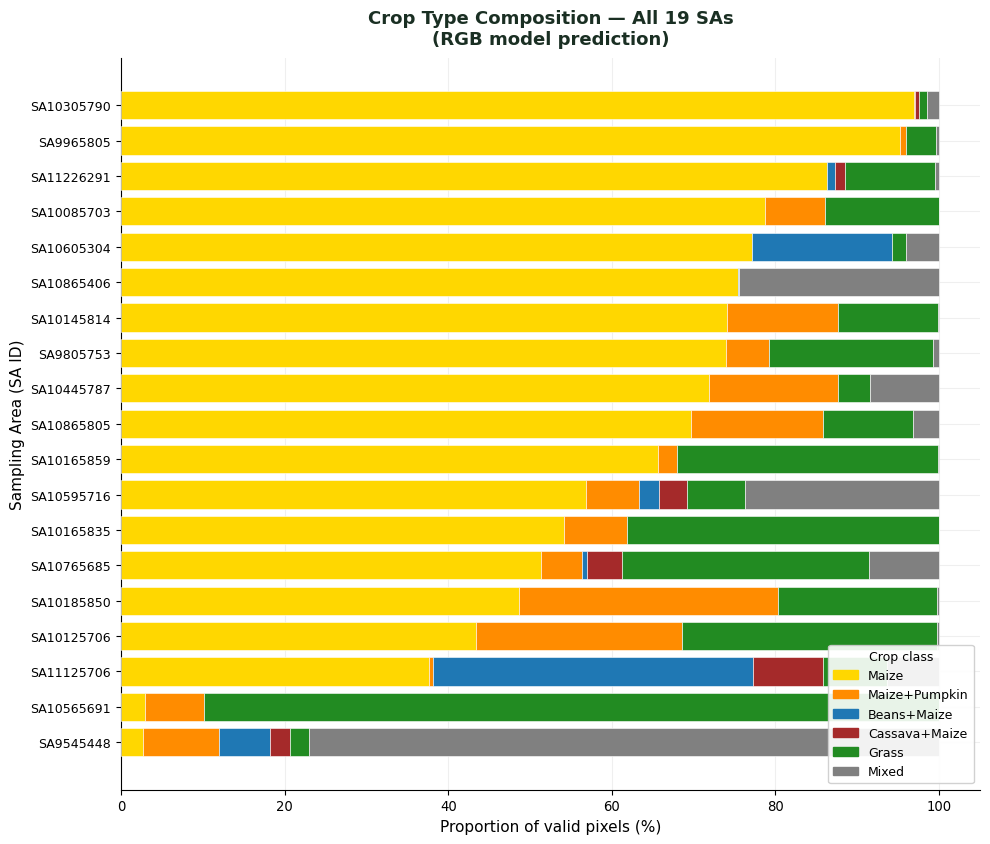

In [31]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 1b — Crop type composition — RGB PREDICTION
# ══════════════════════════════════════════════════════════════════
crop_comp_chart(area_rgb, "RGB Prediction",
                "fig1b_composition_rgb.png",
                "RGB model prediction")

## Figure 1c. Crop composition — MS PREDICTION

Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig1c_composition_ms.png


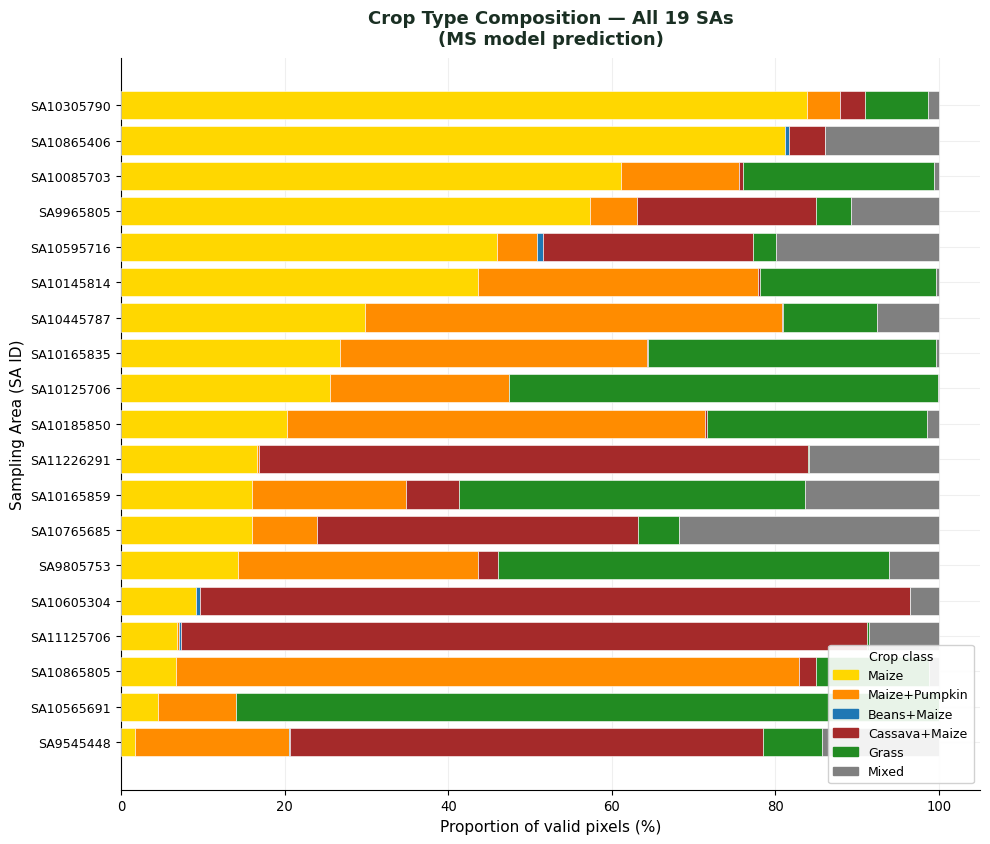

In [32]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 1c — Crop type composition — MS PREDICTION
# ══════════════════════════════════════════════════════════════════
crop_comp_chart(area_ms, "MS Prediction",
                "fig1c_composition_ms.png",
                "MS model prediction")

## Figure 2. Diversity index — all 3 sources grouped

Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig2_diversity_all_sources.png


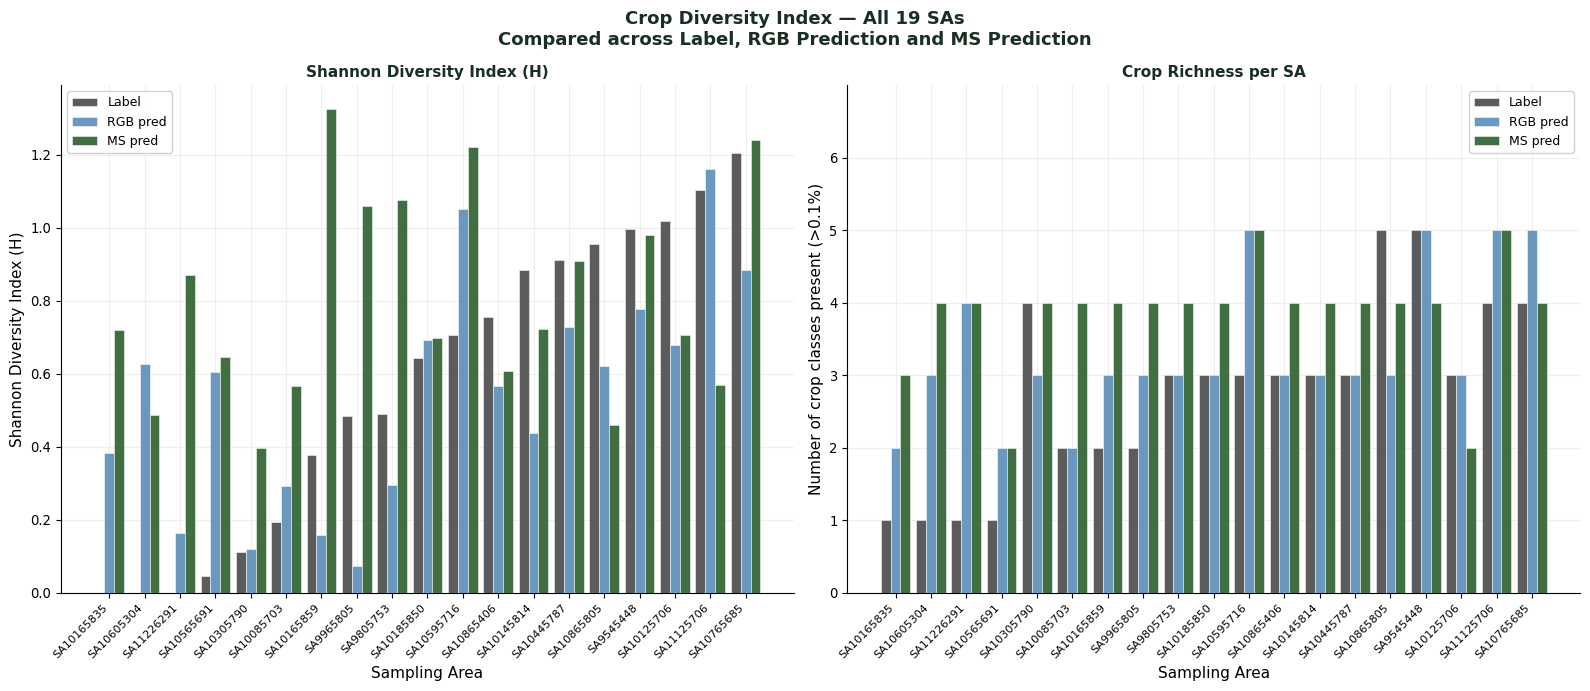

In [45]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 2 — Shannon H and richness — ALL 3 SOURCES side by side
# ══════════════════════════════════════════════════════════════════
src_order  = ["label","rgb_pred","ms_pred"]
src_labels = ["Label","RGB pred","MS pred"]
src_colors = ["#4A4A4A","#5B8DB8","#2C5F2D"]

# Get consistent SA order (sorted by label Shannon H)
sa_order = (div_all[div_all["source"]=="label"]
            .sort_values("Shannon_H",ascending=True)["SA"]
            .astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="white")
fig.suptitle(
    "Crop Diversity Index — All 19 SAs\n"
    "Compared across Label, RGB Prediction and MS Prediction",
    fontsize=13, fontweight="bold", color="#1A2F23"
)

# ── Left: Shannon H ──
x     = np.arange(len(sa_order))
w     = 0.28
for si, (src, lbl, col) in enumerate(
        zip(src_order, src_labels, src_colors)):
    sub  = div_all[div_all["source"]==src].copy()
    sub["SA"] = sub["SA"].astype(str)
    vals = [float(sub.loc[sub["SA"]==sa,"Shannon_H"].values[0])
            if sa in sub["SA"].values else 0.0
            for sa in sa_order]
    axes[0].bar(x + (si-1)*w, vals, w, label=lbl,
                color=col, edgecolor="white",
                linewidth=0.4, zorder=3, alpha=0.9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"SA{s}" for s in sa_order],
    rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Shannon Diversity Index (H)", fontsize=11)
axes[0].set_xlabel("Sampling Area", fontsize=11)
axes[0].legend(fontsize=9, framealpha=0.9)
axes[0].set_title("Shannon Diversity Index (H)",
                   fontsize=11, fontweight="bold", color="#1A2F23")

# ── Right: Crop richness ──
for si, (src, lbl, col) in enumerate(
        zip(src_order, src_labels, src_colors)):
    sub  = div_all[div_all["source"]==src].copy()
    sub["SA"] = sub["SA"].astype(str)
    vals = [int(sub.loc[sub["SA"]==sa,"Crop_richness"].values[0])
            if sa in sub["SA"].values else 0
            for sa in sa_order]
    axes[1].bar(x + (si-1)*w, vals, w, label=lbl,
                color=col, edgecolor="white",
                linewidth=0.4, zorder=3, alpha=0.9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"SA{s}" for s in sa_order],
    rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Number of crop classes present (>0.1%)", fontsize=11)
axes[1].set_xlabel("Sampling Area", fontsize=11)
axes[1].set_ylim(0, 7)
axes[1].set_yticks(range(7))
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].set_title("Crop Richness per SA",
                   fontsize=11, fontweight="bold", color="#1A2F23")

plt.tight_layout()
save = FIG_DIR / "fig2_diversity_all_sources.png"
plt.savefig(save, dpi=180, bbox_inches="tight")
print(f"Saved: {save}"); plt.show()

## Figure 3. Farming system — 3 separate pie charts

Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig3_farming_system.png


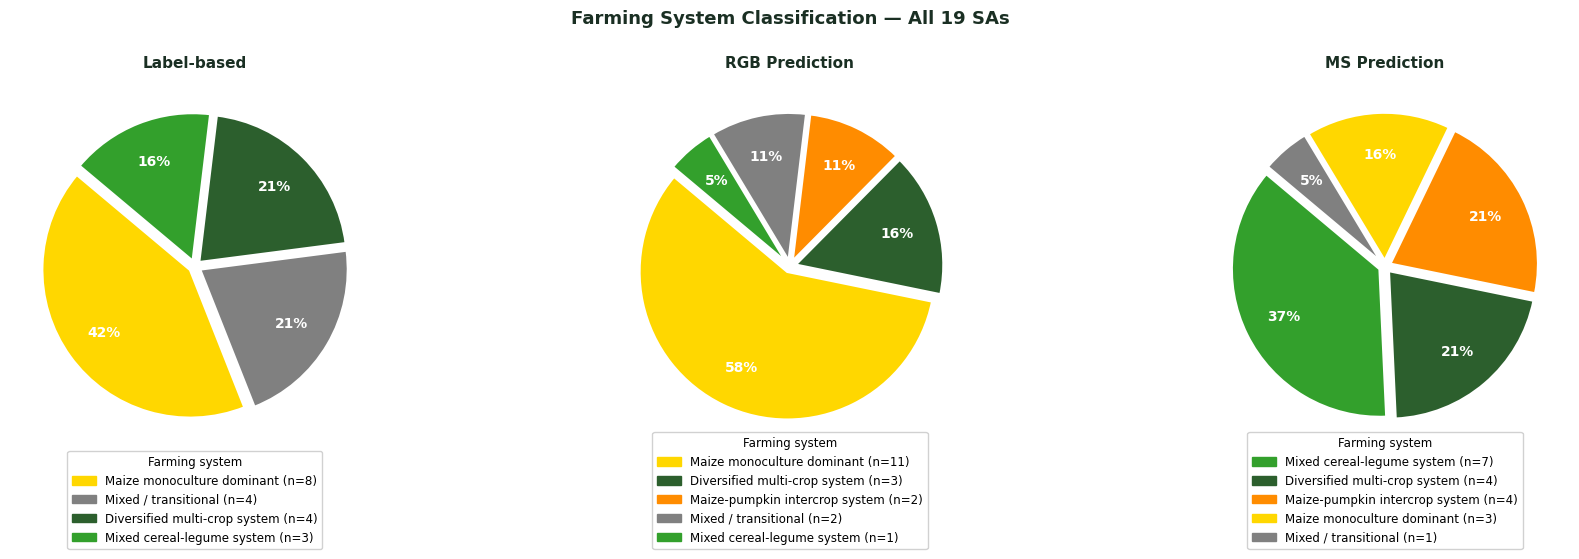

In [35]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 3 — Farming system — 3 separate pie charts
# ══════════════════════════════════════════════════════════════════
fs_colors = {
    "Maize monoculture dominant":    "#FFD700",
    "Mixed cereal-legume system":    "#33A02C",
    "Diversified multi-crop system": "#2C5F2D",
    "Maize-pumpkin intercrop system":"#FF8C00",
    "Mixed / transitional":          "#808080",
}
src_order  = ["label","rgb_pred","ms_pred"]
src_titles = [
    "Label-based",
    "RGB Prediction",
    "MS Prediction",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="white")
fig.suptitle(
    "Farming System Classification — All 19 SAs",
    fontsize=13, fontweight="bold", color="#1A2F23"
)

for ax, src, title in zip(axes, src_order, src_titles):
    sub    = farming_df[farming_df["source"]==src]
    if sub.empty: ax.set_visible(False); continue
    counts = sub["farming_system"].value_counts()
    cols   = [fs_colors.get(k,"#AAAAAA") for k in counts.index]

    wedges, texts, autotexts = ax.pie(
        counts.values, colors=cols,
        autopct="%1.0f%%", pctdistance=0.72,
        startangle=140,
        explode=[0.04]*len(counts),
        wedgeprops={"edgecolor":"white","linewidth":1.8},
    )
    for at in autotexts:
        at.set_fontsize(10); at.set_fontweight("bold")
        at.set_color("white")

    # Count legend inside each panel
    legend_handles = [
        mpatches.Patch(color=fs_colors.get(k,"#AAAAAA"),
                       label=f"{k} (n={v})")
        for k, v in counts.items()
    ]
    ax.legend(handles=legend_handles,
              loc="lower center",
              bbox_to_anchor=(0.5,-0.28),
              fontsize=8.5, frameon=True,
              framealpha=0.9, edgecolor="#CCCCCC",
              title="Farming system", title_fontsize=8.5)
    ax.set_title(title, fontsize=11,
                  fontweight="bold", color="#1A2F23", pad=10)

plt.tight_layout(rect=[0,0.08,1,0.94])
save = FIG_DIR / "fig3_farming_system.png"
plt.savefig(save, dpi=180, bbox_inches="tight")
print(f"Saved: {save}"); plt.show()

## Figure 4. Cultivation intensity — label-based

Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig5_cultivation_intensity.png


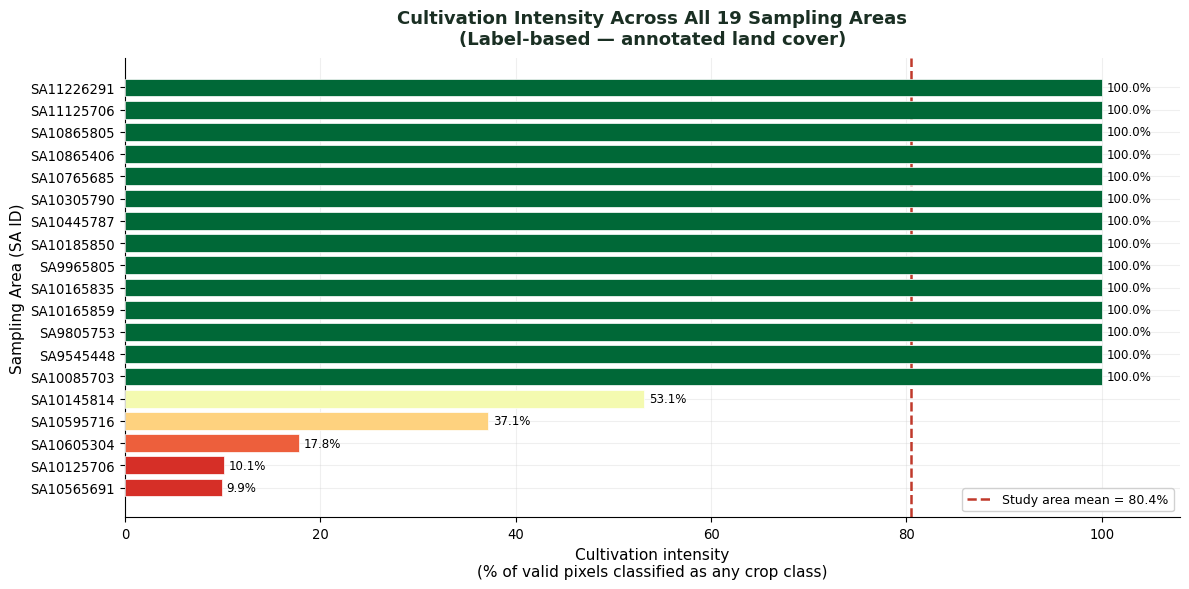

In [37]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 4 — Cultivation intensity — label-based all 19 SAs
# ══════════════════════════════════════════════════════════════════
ci      = area_label.sort_values("crop_intensity_pct", ascending=True).copy()
mean_ci = ci["crop_intensity_pct"].mean()
cmap_v  = ci["crop_intensity_pct"] / 100
colors  = plt.cm.RdYlGn(cmap_v)

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
bars = ax.barh(
    [f"SA{sa}"
     for sa in ci["SA"].astype(str)],
    ci["crop_intensity_pct"],
    color=colors, edgecolor="white", linewidth=0.5, zorder=3
)
ax.axvline(mean_ci, color="#C0392B", linestyle="--",
           linewidth=1.8, label=f"Study area mean = {mean_ci:.1f}%")
ax.set_xlabel("Cultivation intensity\n(% of valid pixels classified as any crop class)",
              fontsize=11)
ax.set_ylabel("Sampling Area (SA ID)", fontsize=11)
ax.set_xlim(0, 108)
ax.set_title(
    "Cultivation Intensity Across All 19 Sampling Areas\n"
    "(Label-based — annotated land cover)",
    fontsize=13, fontweight="bold", color="#1A2F23", pad=10
)
ax.legend(fontsize=9, framealpha=0.9)
for bar, v in zip(bars, ci["crop_intensity_pct"]):
    ax.text(v+0.5, bar.get_y()+bar.get_height()/2,
            f"{v:.1f}%", va="center", fontsize=8.5)

plt.tight_layout()
save = FIG_DIR / "fig5_cultivation_intensity.png"
plt.savefig(save, dpi=180, bbox_inches="tight")
print(f"Saved: {save}"); plt.show()

## Figure 6. FCover composition — RGB vs MS

Auto-expands to all available SAs in fcover_df.
Currently shows test SAs only. Run `06c_fcover_all_sas.ipynb` to extend.

Column mapping: {'Maize': 'Maize_mean', 'Maize+Pumpkin': 'Maize+Pumpkin_mean', 'Beans+Maize': 'Beans+Maize_mean', 'Cassava+Maize': 'Cassava+Maize_mean', 'Mixed': 'Mixed_mean'}
Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig6_fcover_composition.png

Note: Currently showing 3 SA(s).
To extend to all 19 SAs, run 06c_fcover_all_sas.ipynb first,
then reload fcover_df in Cell 1 and re-run this cell.


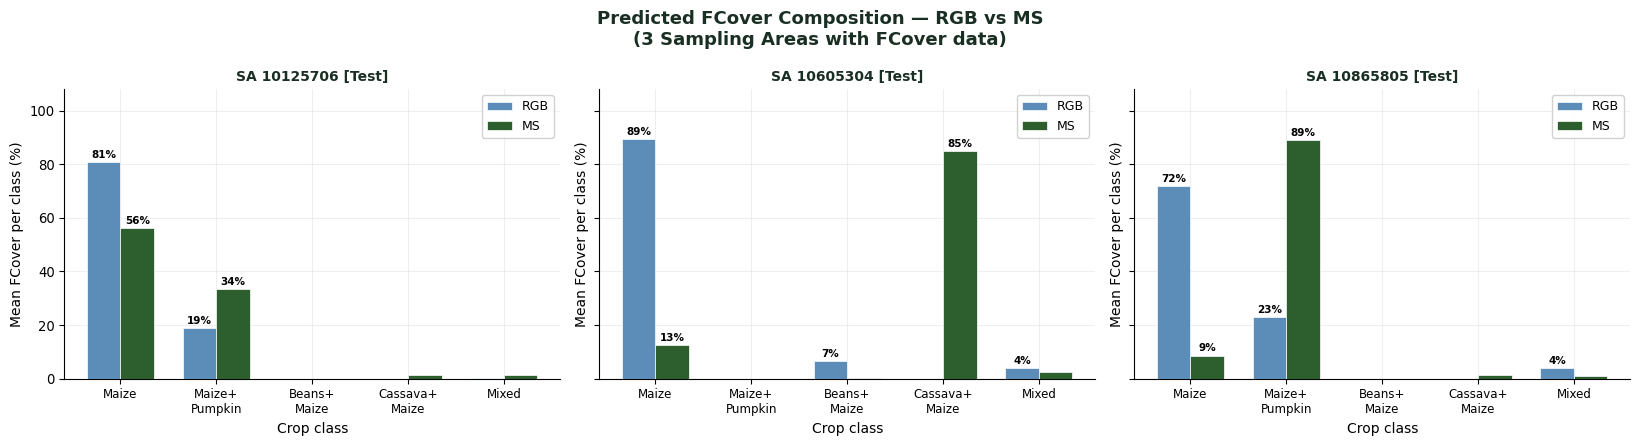

In [38]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 6 — FCover composition — RGB vs MS — available SAs
# Note: includes all SAs in fcover_df (test SAs for now;
#       extend by running 06c_fcover_all_sas.ipynb)
# ══════════════════════════════════════════════════════════════════
CROP_NAMES = ["Maize","Maize+Pumpkin","Beans+Maize","Cassava+Maize","Mixed"]

# Find mean columns robustly
def find_col(df, name):
    for c in df.columns:
        if c.startswith(name) and c.endswith("_mean"):
            return c
    for c in df.columns:
        n2 = name.replace("+","_").replace(" ","_")
        if c.startswith(n2) and c.endswith("_mean"):
            return c
    return None

mean_col_map = {n: find_col(fcover_df, n) for n in CROP_NAMES}
print("Column mapping:", mean_col_map)

avail_sas = sorted(fcover_df["SA"].astype(str).unique())
n_sa      = len(avail_sas)
ncols     = min(3, n_sa)
nrows     = math.ceil(n_sa / ncols)

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols*5.5, nrows*4.5),
                          sharey=True, facecolor="white")
if n_sa == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes.reshape(1, -1)
fig.suptitle(
    f"Predicted FCover Composition — RGB vs MS\n"
    f"({n_sa} Sampling Area{'s' if n_sa>1 else ''} with FCover data)",
    fontsize=13, fontweight="bold", color="#1A2F23"
)

x     = np.arange(len(CROP_NAMES))
width = 0.35

for idx, sa_id in enumerate(avail_sas):
    r, c   = divmod(idx, ncols)
    ax     = axes[r, c]
    df_sa  = fcover_df[fcover_df["SA"].astype(str)==sa_id].copy()
    split  = SPLIT_MAP.get(sa_id, "?")

    for mi, (mod, lbl, col) in enumerate([
        ("rgb_v3","RGB","#5B8DB8"),
        ("ms_v1", "MS", "#2C5F2D"),
    ]):
        row = df_sa[df_sa["modality"]==mod]
        if row.empty: continue
        vals = []
        for n in CROP_NAMES:
            mc = mean_col_map.get(n)
            vals.append(float(row[mc].values[0])
                        if mc and mc in row.columns else 0.0)
        offset = (mi - 0.5) * width
        bars   = ax.bar(x + offset, vals, width,
                        label=lbl, color=col,
                        edgecolor="white", linewidth=0.5, zorder=3)
        for bar, v in zip(bars, vals):
            if v > 3:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.8,
                        f"{v:.0f}%", ha="center", va="bottom",
                        fontsize=7.5, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels([n.replace("+","+\n") for n in CROP_NAMES],
                        fontsize=8.5)
    ax.set_title(f"SA {sa_id} [{split}]",
                  fontsize=10, fontweight="bold", color="#1A2F23")
    ax.set_ylim(0, 108)
    ax.set_ylabel("Mean FCover per class (%)", fontsize=10)
    ax.set_xlabel("Crop class", fontsize=10)
    ax.legend(fontsize=9, framealpha=0.9)

# Hide unused subplots
for idx in range(n_sa, nrows*ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].set_visible(False)

plt.tight_layout()
save = FIG_DIR / "fig6_fcover_composition.png"
plt.savefig(save, dpi=180, bbox_inches="tight")
print(f"Saved: {save}")
print(f"\nNote: Currently showing {n_sa} SA(s).")
print("To extend to all 19 SAs, run 06c_fcover_all_sas.ipynb first,")
print("then reload fcover_df in Cell 1 and re-run this cell.")
plt.show()

## Figure 7. Cultivation intensity comparison — all sources

Saved: E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\fig7_cultivation_comparison.png


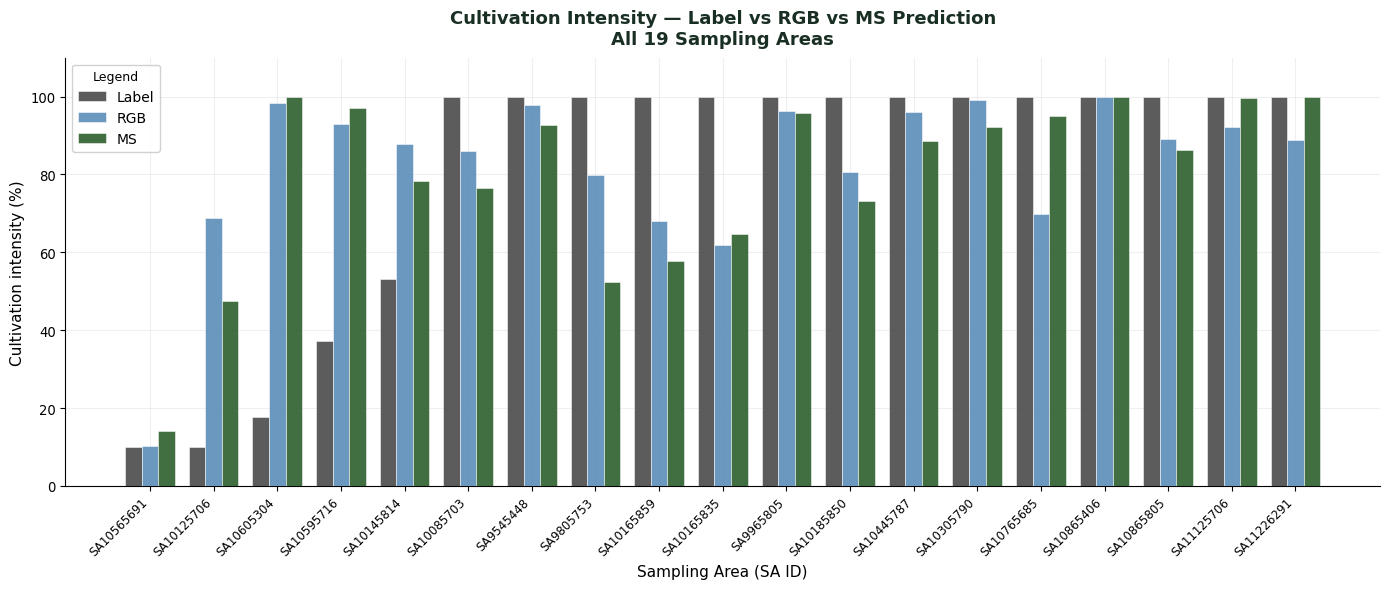

In [40]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 7 — Cultivation intensity: Label vs RGB vs MS comparison
# ══════════════════════════════════════════════════════════════════
merge = area_label[["SA","crop_intensity_pct"]].rename(
    columns={"crop_intensity_pct":"Label"})
merge = merge.merge(
    area_rgb[["SA","crop_intensity_pct"]].rename(
        columns={"crop_intensity_pct":"RGB"}), on="SA", how="left")
merge = merge.merge(
    area_ms[["SA","crop_intensity_pct"]].rename(
        columns={"crop_intensity_pct":"MS"}), on="SA", how="left")
merge = merge.sort_values("Label", ascending=True).copy()

x  = np.arange(len(merge))
w  = 0.26
colors_bar = {"Label":"#4A4A4A","RGB":"#5B8DB8","MS":"#2C5F2D"}

fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
for i, (col_name, color) in enumerate(colors_bar.items()):
    if col_name not in merge.columns: continue
    ax.bar(x + (i-1)*w, merge[col_name],
           w, label=col_name, color=color,
           edgecolor="white", linewidth=0.4, zorder=3, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"SA{sa}"
     for sa in merge["SA"].astype(str)],
    rotation=45, ha="right", fontsize=8.5)
ax.set_ylabel("Cultivation intensity (%)", fontsize=11)
ax.set_xlabel("Sampling Area (SA ID)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_title(
    "Cultivation Intensity — Label vs RGB vs MS Prediction\n"
    "All 19 Sampling Areas",
    fontsize=13, fontweight="bold", color="#1A2F23", pad=10)
ax.legend(fontsize=10, framealpha=0.9, title="Legend",
          title_fontsize=9)
plt.tight_layout()
save = FIG_DIR / "fig7_cultivation_comparison.png"
plt.savefig(save, dpi=180, bbox_inches="tight")
print(f"Saved: {save}"); plt.show()

## Summary

In [ ]:
# ── Summary ───────────────────────────────────────────────────────────────
import os
print("\n" + "="*60)
print("ALL FIGURES SAVED")
print("="*60)
for f in sorted(FIG_DIR.glob("*.png")):
    kb = os.path.getsize(f)/1024
    print(f"  {f.name:50s}  {kb:6.0f} KB")
print(f"\nDirectory: {FIG_DIR}")

In [41]:
import pandas as pd
from pathlib import Path

BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
STATS_DIR = BASE_DIR / "AgriStats"

area_df = pd.read_csv(STATS_DIR / "crop_area_per_sa.csv")

# Label-based — all 19 SAs
print("=== LABEL-BASED — ALL 19 SAs ===")
cols = ["SA","total_valid_ha","total_crop_ha","total_grass_ha","crop_intensity_pct"]
print(area_df[area_df["source"]=="label"][cols].to_string(index=False))

# Prediction-based — all 19 SAs
print("\n=== RGB PREDICTION — ALL 19 SAs ===")
print(area_df[area_df["source"]=="rgb_pred"][cols].to_string(index=False))

print("\n=== MS PREDICTION — ALL 19 SAs ===")
print(area_df[area_df["source"]=="ms_pred"][cols].to_string(index=False))

# Summary stats
for src in ["label","rgb_pred","ms_pred"]:
    sub = area_df[area_df["source"]==src]
    print(f"\n{src} — mean CI: {sub['crop_intensity_pct'].mean():.2f}%  "
          f"total crop ha: {sub['total_crop_ha'].sum():.2f}  "
          f"total valid ha: {sub['total_valid_ha'].sum():.2f}")

=== LABEL-BASED — ALL 19 SAs ===
      SA  total_valid_ha  total_crop_ha  total_grass_ha  crop_intensity_pct
 9545448         13.4383        13.4383          0.0000              100.00
 9805753          1.7846         1.7846          0.0000              100.00
 9965805          0.5909         0.5909          0.0000              100.00
10085703          4.8791         4.8791          0.0000              100.00
10125706         13.3482         1.3500         11.9983               10.11
10145814         14.6890         7.8013          6.8877               53.11
10165835          3.0210         3.0210          0.0000              100.00
10165859          2.8463         2.8463          0.0000              100.00
10185850          4.0391         4.0391          0.0000              100.00
10305790         14.9561        14.9561          0.0000              100.00
10445787          4.4418         4.4418          0.0000              100.00
10565691         17.3676         1.7173         15.6502

In [42]:
div_df = pd.read_csv(STATS_DIR / "crop_diversity_all_sources.csv")

for src in ["label","rgb_pred","ms_pred"]:
    sub = div_df[div_df["source"]==src]
    print(f"\n=== {src} ===")
    print(sub[["SA","Shannon_H","Evenness","Crop_richness"]].to_string(index=False))
    print(f"  Mean H={sub['Shannon_H'].mean():.4f}  "
          f"Min={sub['Shannon_H'].min():.4f}  "
          f"Max={sub['Shannon_H'].max():.4f}  "
          f"Mean richness={sub['Crop_richness'].mean():.1f}")


=== label ===
      SA  Shannon_H  Evenness  Crop_richness
 9545448     0.9970    0.6195              5
 9805753     0.4893    0.3040              3
 9965805     0.4854    0.3016              2
10085703     0.1935    0.1202              2
10125706     1.0198    0.6336              3
10145814     0.8838    0.5491              3
10165835     0.0000    0.0000              1
10165859     0.3768    0.2341              2
10185850     0.6422    0.3990              3
10305790     0.1103    0.0685              4
10445787     0.9129    0.5672              3
10565691     0.0470    0.0292              1
10595716     0.7052    0.4382              3
10605304     0.0000    0.0000              1
10765685     1.2045    0.7484              4
10865406     0.7568    0.4702              3
10865805     0.9558    0.5939              5
11125706     1.1028    0.6852              4
11226291     0.0000    0.0000              1
  Mean H=0.5728  Min=0.0000  Max=1.2045  Mean richness=2.8

=== rgb_pred ===
      SA

In [43]:
farm_df = pd.read_csv(STATS_DIR / "farming_system_classification.csv")

for src in ["label","rgb_pred","ms_pred"]:
    sub = farm_df[farm_df["source"]==src]
    print(f"\n=== {src} ===")
    print(sub[["SA","farming_system","Maize_pct","Maize+Pumpkin_pct",
               "Beans+Maize_pct","Cassava+Maize_pct"]].to_string(index=False))
    print("\nDistribution:")
    print(sub["farming_system"].value_counts().to_string())


=== label ===
      SA                farming_system  Maize_pct  Maize+Pumpkin_pct  Beans+Maize_pct  Cassava+Maize_pct
 9545448    Mixed cereal-legume system       7.78               3.90            15.31               3.99
 9805753    Maize monoculture dominant      86.29               4.98             0.00               0.00
 9965805    Maize monoculture dominant      81.06               0.00             0.00               0.00
10085703    Maize monoculture dominant      95.17               4.83             0.00               0.00
10125706          Mixed / transitional       3.88               4.61             0.00               0.00
10145814 Diversified multi-crop system      34.77               9.03             0.00               0.00
10165835    Maize monoculture dominant     100.00               0.00             0.00               0.00
10165859    Maize monoculture dominant      87.50               0.00             0.00               0.00
10185850    Maize monoculture dominant  

In [44]:
forage_df = pd.read_csv(STATS_DIR / "forage_stats_per_sa.csv")

for src in ["label","rgb_pred","ms_pred"]:
    sub = forage_df[forage_df["source"]==src]
    print(f"\n=== {src} ===")
    print(sub[["SA","grass_area_ha","crop_area_ha",
               "grass_pct_of_total","grass_to_crop_ratio"]].to_string(index=False))
    has_grass = sub[sub["grass_area_ha"]>0]
    print(f"  SAs with grass: {len(has_grass)} of {len(sub)}")
    if len(has_grass)>0:
        print(f"  Mean ratio (where grass>0): "
              f"{has_grass['grass_to_crop_ratio'].mean():.3f}")
        print(f"  Max ratio: {has_grass['grass_to_crop_ratio'].max():.3f} "
              f"(SA{has_grass.loc[has_grass['grass_to_crop_ratio'].idxmax(),'SA']})")


=== label ===
      SA  grass_area_ha  crop_area_ha  grass_pct_of_total  grass_to_crop_ratio
 9545448         0.0000       13.4383                0.00               0.0000
 9805753         0.0000        1.7846                0.00               0.0000
 9965805         0.0000        0.5909                0.00               0.0000
10085703         0.0000        4.8791                0.00               0.0000
10125706        11.9983        1.3500               89.89               8.8876
10145814         6.8877        7.8013               46.89               0.8829
10165835         0.0000        3.0210                0.00               0.0000
10165859         0.0000        2.8463                0.00               0.0000
10185850         0.0000        4.0391                0.00               0.0000
10305790         0.0000       14.9561                0.00               0.0000
10445787         0.0000        4.4418                0.00               0.0000
10565691        15.6502        1.7173

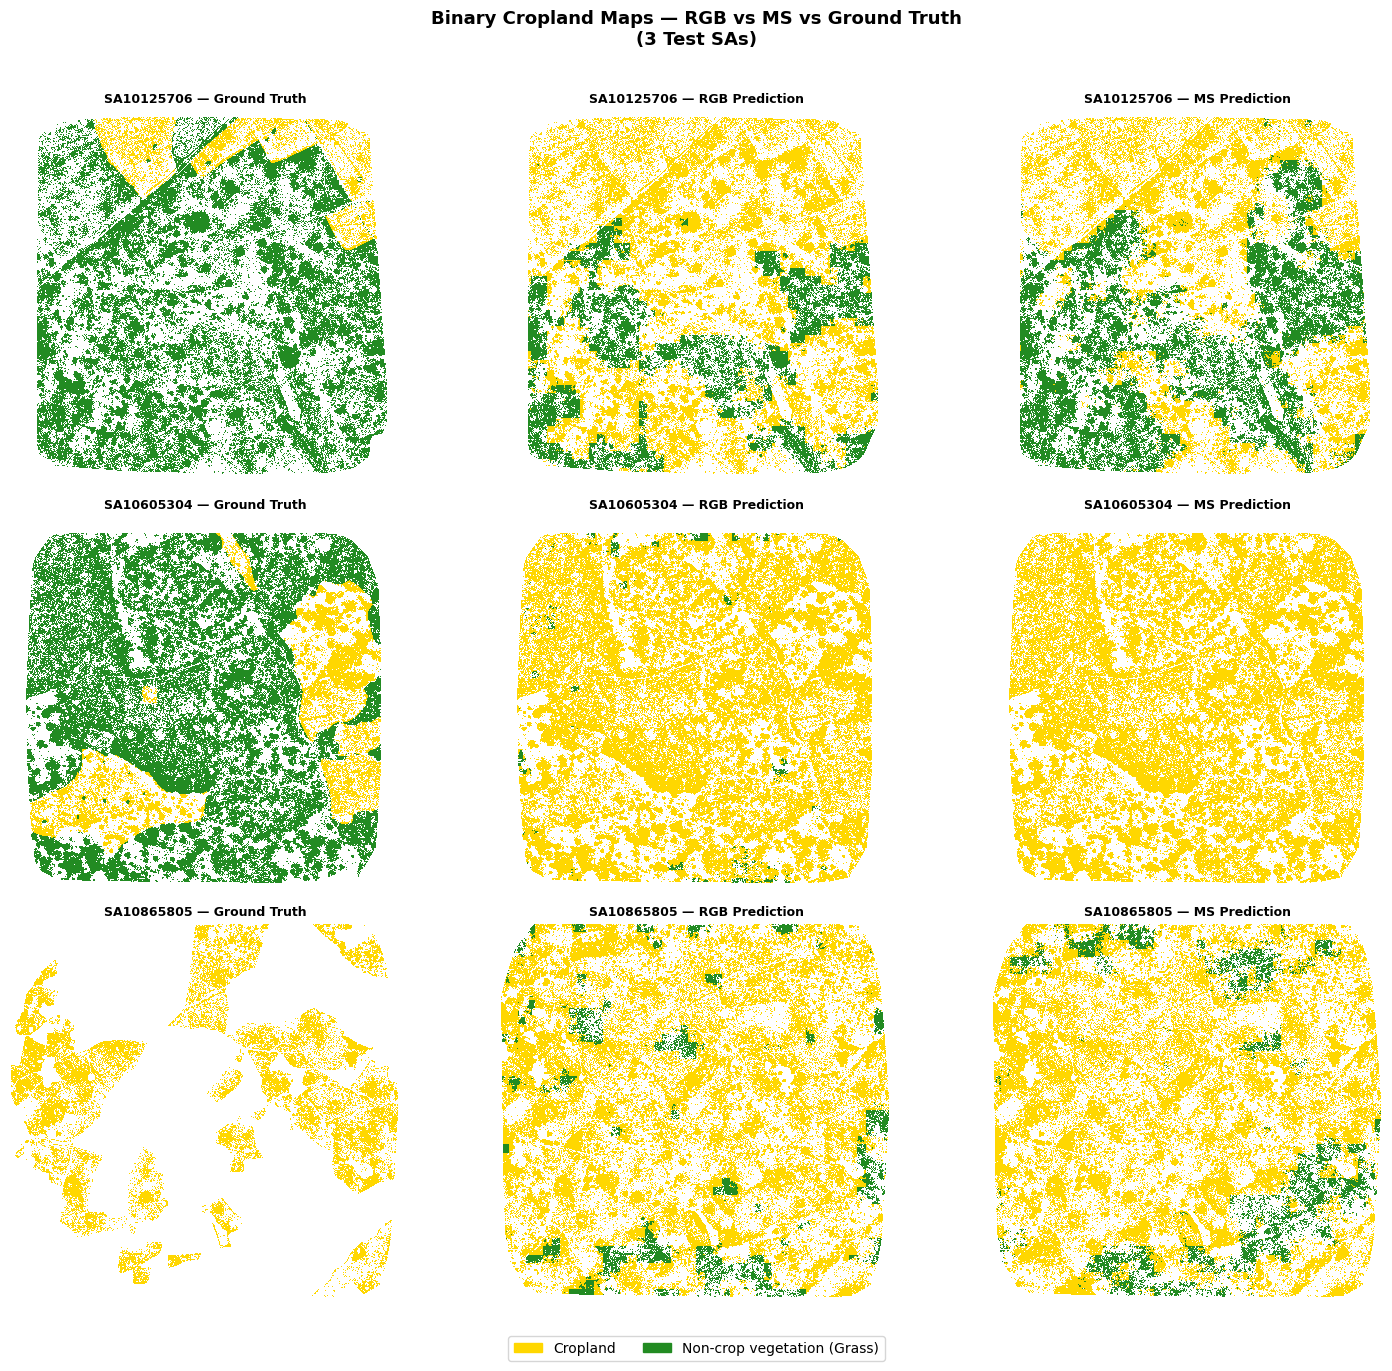

In [48]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from matplotlib.colors import ListedColormap

BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
PRED_DIR  = BASE_DIR / "Predictions"
TEST_SAS  = ["10125706","10605304","10865805"]
IGNORE    = 255

# Binary colormap: 0=non-crop (green), 1=cropland (gold), masked=white
BINARY_CMAP = ListedColormap(["#228B22","#FFD700"])

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
fig.suptitle("Binary Cropland Maps — RGB vs MS vs Ground Truth\n(3 Test SAs)",
             fontsize=13, fontweight="bold")

for row, sa_id in enumerate(TEST_SAS):
    lbl_path = BASE_DIR / "Labels" / f"{sa_id}_labels.tif"
    rgb_path = PRED_DIR / "rgb_v3" / f"{sa_id}_pred_rgb.tif"
    ms_path  = PRED_DIR / "ms_v1"  / f"{sa_id}_pred_ms.tif"

    for col, (path, title) in enumerate([
        (lbl_path, "Ground Truth"),
        (rgb_path, "RGB Prediction"),
        (ms_path,  "MS Prediction"),
    ]):
        with rasterio.open(path) as src:
            data = src.read(1)

        # Reclassify: non-crop veg = 0, cropland = 1, background = masked
        binary = np.where(
            data == IGNORE, np.nan,
            np.where(data == 4, 0, 1)  # Grass=0, all crops=1
        )
        masked = np.ma.masked_invalid(binary)

        axes[row, col].imshow(masked, cmap=BINARY_CMAP,
                               vmin=0, vmax=1,
                               interpolation="nearest")
        axes[row, col].set_title(f"SA{sa_id} — {title}",
                                  fontsize=9, fontweight="bold")
        axes[row, col].axis("off")

patches = [
    mpatches.Patch(color="#FFD700", label="Cropland"),
    mpatches.Patch(color="#228B22", label="Non-crop vegetation (Grass)"),
]
fig.legend(handles=patches, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, 0.01), fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig(BASE_DIR / "binary_cropland_maps.png", dpi=150, bbox_inches="tight")
plt.show()